In [2]:
# COLAB SETUP

%cd /content
!rm -rf /content/proto-tsrl
!git clone https://github.com/haiyan-wang/proto-tsrl.git /content/proto-tsrl
%cd /content/proto-tsrl

from google.colab import drive
drive.mount('/content/drive')

import sys
import os

project_root = os.getcwd()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(project_root)

/content
Cloning into '/content/proto-tsrl'...
remote: Enumerating objects: 276, done.
remote: Counting objects: 100% (276/276), done.
remote: Compressing objects: 100% (223/223), done.
remote: Total 276 (delta 132), reused 131 (delta 49), pack-reused 0 (from 0)
Receiving objects: 100% (276/276), 978.96 KiB | 3.00 MiB/s, done.
Resolving deltas: 100% (132/132), done.
/content/proto-tsrl
Mounted at /content/drive
/content/proto-tsrl


In [3]:
!pip install pacmap

In [28]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix

import pacmap

from src.utils.training_utils import _pairwise_cos_sim
from src.utils.sampling_utils import TimeSeriesDataset
from src.experiments.ppg.ppg_model import PPGModel
from src.experiments.ppg.ppg_data_utils import *

In [5]:
# SETTINGS

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# device
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(DEVICE)

# data quality
INCLUDE_CLEAN_DATA = True
INCLUDE_SEMINOISY_DATA = True
INCLUDE_NOISY_DATA = False
TRAIN_SET_SIZE = int(1e4)

# logging
SAVE_DIR = "/content/drive/MyDrive/Duke/Senior Year/Thesis/experiments/ppg"

# architecture
REPR_DIMS = [10, 50, 100]
MODELS = {}
for dim in REPR_DIMS:
    model_list = {}

    ckpt_dir = f"{SAVE_DIR}/checkpoints/dim{dim}"
    for ckpt_file in os.listdir(ckpt_dir):
        epoch = ckpt_file[10:-3]
        ckpt = torch.load(f"{ckpt_dir}/{ckpt_file}", map_location = "cpu")
        MODEL = PPGModel(representation_dimension = dim)
        MODEL.load_state_dict(ckpt)
        MODEL = MODEL.to(DEVICE)
        if torch.cuda.device_count() > 1:
            MODEL = nn.DataParallel(MODEL)
        elif not isinstance(MODEL, nn.DataParallel):
            MODEL = nn.DataParallel(MODEL)
        MODEL.eval()

        model_list[epoch] = MODEL

    MODELS[dim] = model_list

cuda:0


In [6]:
# LOAD DATA

X_train, y_train = load_data(
    file_path = '/content/drive/MyDrive/Duke/Senior Year/Thesis/ppg_data/',
    clean = INCLUDE_CLEAN_DATA,
    seminoisy = INCLUDE_SEMINOISY_DATA,
    noisy = INCLUDE_NOISY_DATA,
    dataset = 'train',
    return_labels = True
)
indices = np.random.default_rng(SEED).permutation(X_train.shape[0])
X_train, y_train = X_train[indices][:TRAIN_SET_SIZE], y_train[indices][:TRAIN_SET_SIZE]

X_test, y_test = load_data(
    file_path = '/content/drive/MyDrive/Duke/Senior Year/Thesis/ppg_data/',
    clean = INCLUDE_CLEAN_DATA,
    seminoisy = INCLUDE_SEMINOISY_DATA,
    noisy = INCLUDE_NOISY_DATA,
    dataset = 'test',
    return_labels = True
)

# RESHAPE HERE WHEN collate_fn = None
X_train, X_test = np.transpose(X_train, (0, 2, 1)), np.transpose(X_test, (0, 2, 1))

print(f'X_train shape: {X_train.shape}')
print(f'Train set positive samples: {np.sum(y_train)}')
print(f'X_test shape: {X_test.shape}')
print(f'Test set positive samples: {np.sum(y_test)}')

X_train shape: (10000, 1, 800)
Train set positive samples: 3702
X_test shape: (5278, 1, 800)
Test set positive samples: 747


In [7]:
# GENERATE REPRESENTATIONS

with torch.inference_mode():

    X_train_tensor, X_test_tensor = torch.tensor(X_train, dtype = torch.float32), torch.tensor(X_test, dtype = torch.float32)

    for dim in REPR_DIMS:
        model = MODELS[dim]['epoch15']
        repr_train, repr_test = model(X_train_tensor), model(X_test_tensor)
        repr_train, repr_test = repr_train.cpu().numpy(), repr_test.cpu().numpy()

        np.savetxt(f'{SAVE_DIR}/test_reprs/prototsrl{dim}-repr-train.csv', repr_train, delimiter = ',')
        np.savetxt(f'{SAVE_DIR}/test_reprs/prototsrl{dim}-repr-test.csv', repr_test, delimiter = ',')

In [8]:
# LOAD TRAIN AND TEST SET REPRESENTATIONS AND CREATE DATALOADERS

repr = {}
for dim in REPR_DIMS:
    repr[dim] = {}
    for repr_set in ['train', 'test']:
        repr[dim][repr_set] = pd.read_csv(f'{SAVE_DIR}/test_reprs/prototsrl{dim}-repr-{repr_set}.csv', header = None).values

# Convert to tensors
y_tensors = {}
y_tensors['train'] = torch.tensor(y_train, dtype = torch.float32).unsqueeze(1)
y_tensors['test'] = torch.tensor(y_test, dtype = torch.float32).unsqueeze(1)

repr_loaders = {}
for dim in REPR_DIMS:
    repr_loaders[dim] = {}
    for repr_set in ['train', 'test']:
        X_tensor = torch.tensor(repr[dim][repr_set], dtype = torch.float32)
        X_dataset = TensorDataset(X_tensor, y_tensors[repr_set])
        if repr_set == 'train':
            repr_loaders[dim][repr_set] = DataLoader(X_dataset, batch_size = 256, shuffle = True)
        else:
            repr_loaders[dim][repr_set] = DataLoader(X_dataset, batch_size = X_tensor.size(0), shuffle = False)

# Classification Tasks

In [9]:
# SIMPLE MODELS

lr_clf = LogisticRegression(max_iter = 500, random_state = SEED)
dt_clf = DecisionTreeClassifier(min_samples_split = 5)
rf_clf = RandomForestClassifier(n_estimators = 100)

sample_weights = compute_sample_weight(class_weight = "balanced", y = y_train)

for dim in REPR_DIMS:
    print(f'===== {dim} dimensional representations =====')

    df_train, df_test = repr[dim]['train'], repr[dim]['test']
    ss = StandardScaler().fit(df_train)
    df_train, df_test = ss.transform(df_train), ss.transform(df_test)

    lr_clf.fit(df_train, y_train) #, sample_weight = sample_weights)
    dt_clf.fit(df_train, y_train) #, sample_weight = sample_weights)
    rf_clf.fit(df_train, y_train) #, sample_weight = sample_weights)

    y_pred_lr = lr_clf.predict(df_test)
    y_pred_dt = dt_clf.predict(df_test)
    y_pred_rf = rf_clf.predict(df_test)

    acc_lr = accuracy_score(y_test, y_pred_lr)
    acc_dt = accuracy_score(y_test, y_pred_dt)
    acc_rf = accuracy_score(y_test, y_pred_rf)

    print(f'acc_lr = {round(acc_lr, 3)} | acc_dt = {round(acc_dt, 3)} | acc_rf = {round(acc_rf, 3)}')
    print('LR')
    print(confusion_matrix(y_test, y_pred_lr))
    print('DT')
    print(confusion_matrix(y_test, y_pred_dt))
    print('RF')
    print(confusion_matrix(y_test, y_pred_rf))

===== 10 dimensional representations =====
acc_lr = 0.697 | acc_dt = 0.673 | acc_rf = 0.762
LR
[[3245 1286]
 [ 312  435]]
DT
[[2963 1568]
 [ 157  590]]
RF
[[3356 1175]
 [  83  664]]
===== 50 dimensional representations =====
acc_lr = 0.688 | acc_dt = 0.679 | acc_rf = 0.778
LR
[[3048 1483]
 [ 164  583]]
DT
[[3000 1531]
 [ 164  583]]
RF
[[3429 1102]
 [  69  678]]
===== 100 dimensional representations =====
acc_lr = 0.673 | acc_dt = 0.702 | acc_rf = 0.762
LR
[[2915 1616]
 [ 110  637]]
DT
[[3058 1473]
 [ 100  647]]
RF
[[3352 1179]
 [  75  672]]


In [10]:
# MLP

class mlp_clf(nn.Module):
    def __init__(self, input_dim, hidden_dim1 = 64, hidden_dim2 = 128, hidden_dim3 = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, hidden_dim3),
            nn.ReLU(),
            nn.Linear(hidden_dim3, 1)
        )

    def forward(self, x):
        return self.net(x)  # logits

def mlpclf_train(
        model,
        dataloader,
        device,
        criterion,
        optimizer,
        n_epochs,
        log_interval = 10
    ):

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0

        for xb, yb in dataloader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)

        epoch_loss = running_loss / len(dataloader.dataset)

        if (epoch+1) % log_interval == 0:
            print(f"Epoch {epoch+1:02d}/{n_epochs} - Train Loss: {epoch_loss:.4f}")

def mlpclf_eval(
        model,
        dataloader,
        device
    ):

    model.eval()

    all_probs = []
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.sigmoid(logits)

            preds = (probs >= 0.5).float()

            all_probs.extend(probs.cpu().numpy().ravel())
            all_preds.extend(preds.cpu().numpy().ravel())
            all_targets.extend(yb.numpy().ravel())

    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    print(f"Accuracy          : {accuracy_score(all_targets, all_preds):.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(all_targets, all_preds))

In [11]:
mlps = {}
opts = {}
for dim in REPR_DIMS:
    mlps[dim] = mlp_clf(input_dim = dim).to(DEVICE)
    opts[dim] = torch.optim.Adam(mlps[dim].parameters(), lr = 1e-3)

n_neg, n_pos = np.sum(y_train == 0), np.sum(y_train == 1)
pos_weight = torch.tensor([n_neg / n_pos], dtype = torch.float32).to(DEVICE)
criterion = nn.BCEWithLogitsLoss() # pos_weight = pos_weight)

In [16]:
print('===== 10D =====')
mlpclf_train(
    model = mlps[10],
    dataloader = repr_loaders[10]['train'],
    device = DEVICE,
    criterion = criterion,
    optimizer = opts[10],
    n_epochs = 100
)

print('===== 50D =====')
mlpclf_train(
    model = mlps[50],
    dataloader = repr_loaders[50]['train'],
    device = DEVICE,
    criterion = criterion,
    optimizer = opts[50],
    n_epochs = 100
)

print('===== 100D =====')
mlpclf_train(
    model = mlps[100],
    dataloader = repr_loaders[100]['train'],
    device = DEVICE,
    criterion = criterion,
    optimizer = opts[100],
    n_epochs = 100
)

===== 10D =====
Epoch 10/100 - Train Loss: 0.2138
Epoch 20/100 - Train Loss: 0.2330
Epoch 30/100 - Train Loss: 0.1993
Epoch 40/100 - Train Loss: 0.1927
Epoch 50/100 - Train Loss: 0.1942
Epoch 60/100 - Train Loss: 0.2022
Epoch 70/100 - Train Loss: 0.1886
Epoch 80/100 - Train Loss: 0.2149
Epoch 90/100 - Train Loss: 0.1911
Epoch 100/100 - Train Loss: 0.1895
===== 50D =====
Epoch 10/100 - Train Loss: 0.1595
Epoch 20/100 - Train Loss: 0.1870
Epoch 30/100 - Train Loss: 0.1467
Epoch 40/100 - Train Loss: 0.1422
Epoch 50/100 - Train Loss: 0.1801
Epoch 60/100 - Train Loss: 0.1297
Epoch 70/100 - Train Loss: 0.1309
Epoch 80/100 - Train Loss: 0.1294
Epoch 90/100 - Train Loss: 0.2034
Epoch 100/100 - Train Loss: 0.1505
===== 100D =====
Epoch 10/100 - Train Loss: 0.1269
Epoch 20/100 - Train Loss: 0.1529
Epoch 30/100 - Train Loss: 0.1227
Epoch 40/100 - Train Loss: 0.1304
Epoch 50/100 - Train Loss: 0.1284
Epoch 60/100 - Train Loss: 0.1216
Epoch 70/100 - Train Loss: 0.1328
Epoch 80/100 - Train Loss: 0.11

In [17]:
print('===== 10D =====')
mlpclf_eval(
    model = mlps[10],
    dataloader = repr_loaders[10]['test'],
    device = DEVICE
)

print('===== 50D =====')
mlpclf_eval(
    model = mlps[50],
    dataloader = repr_loaders[50]['test'],
    device = DEVICE
)

print('===== 100D =====')
mlpclf_eval(
    model = mlps[100],
    dataloader = repr_loaders[100]['test'],
    device = DEVICE
)

===== 10D =====
Accuracy          : 0.8204

Confusion Matrix:
[[3683  848]
 [ 100  647]]
===== 50D =====
Accuracy          : 0.7675

Confusion Matrix:
[[3387 1144]
 [  83  664]]
===== 100D =====
Accuracy          : 0.6986

Confusion Matrix:
[[2995 1536]
 [  55  692]]


# Prototype Evolution

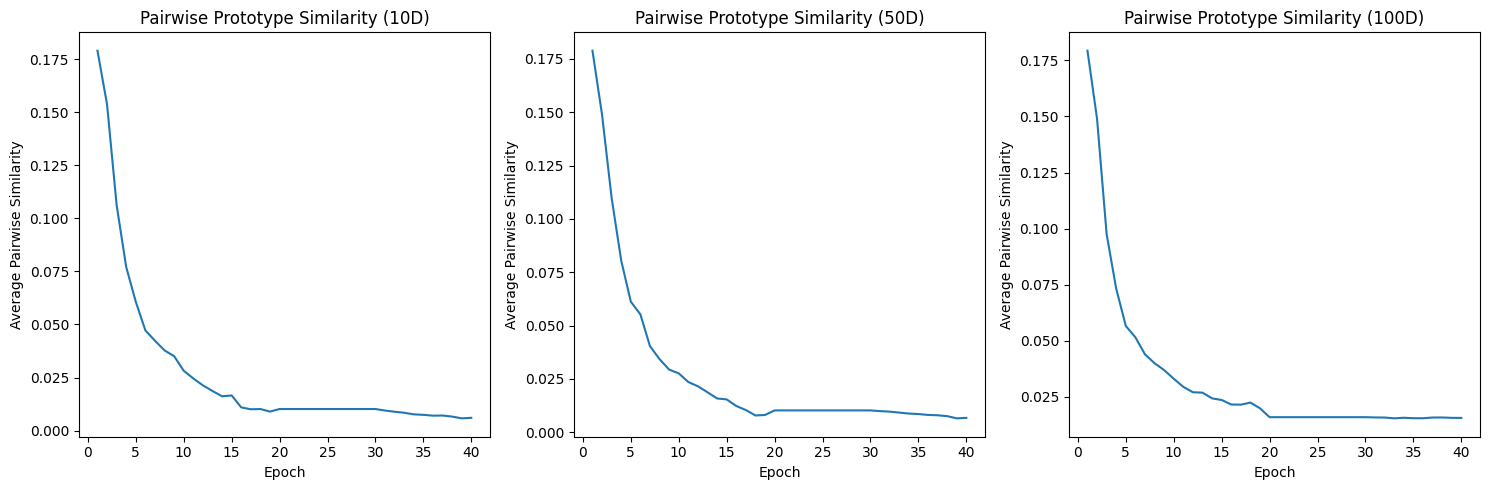

In [37]:
'''
sim = _pairwise_cos_sim(prototype_vectors, prototype_vectors, eps = eps)

n = sim.size(0)
if n < 2:
    return sim.new_tensor(0.0)

off_diag_mask = ~torch.eye(n, dtype = torch.bool, device = sim.device)
off_diag = sim[off_diag_mask]
penalty = torch.clamp(off_diag - threshold, min=0.0)

return penalty.mean()
'''


def prototype_evolution(dim):

    epoch_sims = []
    for epoch, m in MODELS[dim].items():
        model = m.module
        epoch_num = int(epoch[5:])

        prototype_sim = 0

        for prototype_layer in model.prototype_layers:
            prototype_vectors = prototype_layer.prototype_vectors
            sim = _pairwise_cos_sim(prototype_vectors, prototype_vectors, eps = 1e-8)

            n = sim.size(0)
            if n < 2:
                return sim.new_tensor(0.0)

            off_diag_mask = ~torch.eye(n, dtype = torch.bool, device = sim.device)
            off_diag = sim[off_diag_mask]
            prototype_sim += off_diag.mean()

        prototype_sim /= len(model.prototype_layers)
        epoch_sims.append(prototype_sim.item())

    return [*range(1, len(epoch_sims) + 1)], epoch_sims

fig, axs = plt.subplots(1, 3, figsize = (15, 5), tight_layout = True)

for i, dim in enumerate(REPR_DIMS):
    axs[i].plot(*prototype_evolution(dim))
    axs[i].set_title(f'Pairwise Prototype Similarity ({dim}D)')
    axs[i].set_xlabel('Epoch')
    axs[i].set_ylabel('Average Pairwise Similarity')